# Craigslist Price Tier Modeling Notebook — Organized Stages 1–9

This notebook combines the group work into the required stage order. Code cells are reorganized from the existing notebooks without adding new modeling code.


# Setup: Load Data and Libraries


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, Embedding, LSTM, Dense, Dropout, Input, Concatenate
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

DATA_URL = "https://raw.githubusercontent.com/OPIM5512-mdk23002/myscrapers-mdk23002/main/data/final_modeling_listings.csv"

df = pd.read_csv(DATA_URL)

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (483, 24)
Columns:
['post_id', 'run_id', 'scraped_at', 'price', 'year', 'make', 'model', 'mileage', 'transmission', 'drivetrain', 'fuel_type', 'engine_cylinders', 'condition', 'color', 'body_type', 'title_status', 'city', 'state', 'zip_code', 'image_url', 'source_txt', 'combined_text', 'combined_text_len', 'has_combined_text']


,post_id,run_id,scraped_at,price,year,make,model,mileage,transmission,drivetrain,...,body_type,title_status,city,state,zip_code,image_url,source_txt,combined_text,combined_text_len,has_combined_text
0,7928977431,20260429110043,2026-04-29T11:00:43Z,3750.0,2005,Jeep,Liberty,99000.0,automatic,4wd,...,suv,clean,Westfield,MA,NaN,NaN,scrapes/20260429110043/7928977431.txt,2005 jeep liberty sport 4x4 for sale by owner ...,1156,True
1,7929999620,20260429110043,2026-04-29T11:00:43Z,7800.0,2011,Honda,CR-V,146000.0,automatic,4wd,...,suv,clean,Fairfield,CT,NaN,NaN,scrapes/20260429110043/7929999620.txt,2011 honda cr-v ex for sale by owner - fairfie...,1059,True
2,7930043364,20260429110043,2026-04-29T11:00:43Z,14200.0,2015,Jeep,Wrangler,37500.0,automatic,4WD,...,suv,clean,New Haven,CT,NaN,NaN,scrapes/20260429110043/7930043364.txt,2015 jeep wrangler unlimited rubicon for sale ...,1039,True
3,7927868905,20260429140043,2026-04-29T14:00:43Z,7900.0,2014,Jeep,Wrangler,163000.0,manual,4wd,...,suv,clean,Shelton,CT,NaN,NaN,scrapes/20260429140043/7927868905.txt,2014 jeep wrangler sport for sale by owner - s...,1716,True
4,7927877622,20260429150247,2026-04-29T15:02:47Z,6985.0,1997,Jaguar,Xk8,61000.0,automatic,rwd,...,convertible,clean,Branford,CT,NaN,NaN,scrapes/20260429150247/7927877622.txt,1997 jaguar xk8 convertible coupe for sale - b...,3129,True


# Stage 1: Define the Prediction Target

Convert asking price into low, medium, and high price tiers using quantile bins.


In [59]:
df_model = df.copy()

# Match the structured notebook's target setup:
# use actual_price if available; otherwise use price.
if "actual_price" in df_model.columns:
    df_model["price_num"] = pd.to_numeric(df_model["actual_price"], errors="coerce")
else:
    df_model["price_num"] = pd.to_numeric(df_model["price"], errors="coerce")

# Match the structured notebook's basic price filters.
df_model = df_model.dropna(subset=["price_num"])
df_model = df_model[(df_model["price_num"] > 500) & (df_model["price_num"] < 100000)].copy()

# Create three balanced price tiers.
df_model["price_tier"] = pd.qcut(
    df_model["price_num"],
    q=3,
    labels=["low", "medium", "high"]
)

print("Shape after target cleaning:", df_model.shape)

tier_counts = df_model["price_tier"].value_counts().sort_index()
display(tier_counts)

price_tier_summary = (
    df_model.groupby("price_tier", observed=False)["price_num"]
    .agg(["min", "max", "count"])
)

display(price_tier_summary)

Shape after target cleaning: (465, 26)


,count
price_tier,
low,157
medium,154
high,154


,min,max,count
price_tier,,,
low,1000.0,6500.0,157
medium,6700.0,11900.0,154
high,11998.0,89995.0,154


# Stage 2: Create the Clean Modeling Dataset

Create one clean dataframe with structured fields, text fields, and the target label.


In [60]:
def clean_text_value(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = re.sub(r"\s+", " ", x)
    return x.strip()

# Prefer the pipeline-created combined_text field.
if "combined_text" in df_model.columns:
    df_model["combined_text"] = df_model["combined_text"].apply(clean_text_value)
else:
    # Fallback only if the final pipeline field is unavailable.
    text_parts = []

    if "title" in df_model.columns:
        text_parts.append(df_model["title"].fillna("").astype(str))
    else:
        text_parts.append(pd.Series([""] * len(df_model), index=df_model.index))

    if "description" in df_model.columns:
        text_parts.append(df_model["description"].fillna("").astype(str))
    else:
        text_parts.append(pd.Series([""] * len(df_model), index=df_model.index))

    df_model["combined_text"] = (text_parts[0] + " " + text_parts[1]).apply(clean_text_value)

print("Rows with non-empty combined_text:", (df_model["combined_text"].str.len() > 0).sum())
print("Total rows:", len(df_model))

# Check whether any combined_text accidentally looks like a path instead of real text.
path_like_text = df_model["combined_text"].str.contains(r"scrapes/|gs://|\.txt", regex=True, na=False)
print("Rows where combined_text looks like a file path:", path_like_text.sum())

display(df_model[["price_num", "price_tier", "combined_text"]].head())

Rows with non-empty combined_text: 465
Total rows: 465
Rows where combined_text looks like a file path: 0


,price_num,price_tier,combined_text
0,3750.0,low,2005 jeep liberty sport 4x4 for sale by owner ...
1,7800.0,medium,2011 honda cr-v ex for sale by owner - fairfie...
2,14200.0,high,2015 jeep wrangler unlimited rubicon for sale ...
3,7900.0,medium,2014 jeep wrangler sport for sale by owner - s...
4,6985.0,medium,1997 jaguar xk8 convertible coupe for sale - b...


In [61]:
# Price leakage check

# Because combined_text comes from scraped listing text, we should check
# whether the actual asking price appears directly in the text.
# If the exact price appears often, the text model may be learning the target
# too directly instead of learning descriptive price signals.

def price_appears_in_text(row):
    if pd.isna(row["price_num"]):
        return False

    price_int = int(row["price_num"])
    text = str(row["combined_text"]).lower()

    price_variants = [
        str(price_int),
        f"{price_int:,}",
        f"${price_int}",
        f"${price_int:,}"
    ]

    return any(variant.lower() in text for variant in price_variants)

df_model["price_appears_in_text"] = df_model.apply(price_appears_in_text, axis=1)

print("Rows where exact price appears in combined_text:")
print(df_model["price_appears_in_text"].sum())

display(
    df_model.loc[
        df_model["price_appears_in_text"],
        ["price_num", "price_tier", "combined_text"]
    ].head()
)

Rows where exact price appears in combined_text:
9


,price_num,price_tier,combined_text
28,7000.0,medium,"1999 chevy c3500 for sale by owner - trumbull,..."
83,7000.0,medium,"1999 chevy c3500 for sale by owner - trumbull,..."
101,3200.0,low,2011 honda civic cng for sale by owner - water...
151,4900.0,low,"2012 hyundai elantra for sale - branford, ct -..."
229,3900.0,low,"2011 bmw 328ix for sale by owner - new haven, ..."


I checked whether the exact asking price appeared inside 'combined_text'. This is important because the text model should learn descriptive listing signals, not simply memorize the price value from the text. If exact prices appear in only a small number of rows, I will leave the text field as-is and note this as a limitation. If exact prices appear frequently, those values should be removed before vectorization.

In [62]:
if "source_txt" in df_model.columns:
    print(df_model["source_txt"].dropna().astype(str).head(10).tolist())

['scrapes/20260429110043/7928977431.txt', 'scrapes/20260429110043/7929999620.txt', 'scrapes/20260429110043/7930043364.txt', 'scrapes/20260429140043/7927868905.txt', 'scrapes/20260429150247/7927877622.txt', 'scrapes/20260429190051/7927910615.txt', 'scrapes/20260429190051/7929745175.txt', 'scrapes/20260429210038/7927941456.txt', 'scrapes/20260430090025/7930969658.txt', 'scrapes/20260430090025/7930259503.txt']


##Structured Processing for Combined Model

In [63]:
def clean_numeric(series):
    return (
        series
        .astype(str)
        .str.replace(r"[^\d.]+", "", regex=True)
        .str.strip()
        .replace("", np.nan)
        .pipe(pd.to_numeric, errors="coerce")
    )

# Numeric fields
if "year" in df_model.columns:
    df_model["year_num"] = clean_numeric(df_model["year"])

if "mileage" in df_model.columns:
    df_model["mileage_num"] = clean_numeric(df_model["mileage"])

if "engine_cylinders" in df_model.columns:
    df_model["engine_cylinders_num"] = clean_numeric(df_model["engine_cylinders"])

if "year_num" in df_model.columns:
    df_model["vehicle_age"] = 2026 - df_model["year_num"]

if "mileage_num" in df_model.columns and "vehicle_age" in df_model.columns:
    df_model["miles_per_year"] = df_model["mileage_num"] / df_model["vehicle_age"].replace(0, np.nan)

candidate_numeric = [
    "year_num",
    "mileage_num",
    "vehicle_age",
    "miles_per_year",
    "engine_cylinders_num"
]

candidate_categorical = [
    "make",
    "model",
    "transmission",
    "drivetrain",
    "fuel_type",
    "condition",
    "color",
    "body_type",
    "title_status"
]

numeric_features = [col for col in candidate_numeric if col in df_model.columns]
categorical_features = [col for col in candidate_categorical if col in df_model.columns]

model_cols = (
    ["post_id", "price_num", "price_tier", "combined_text"]
    + numeric_features
    + categorical_features
)

model_cols = [col for col in model_cols if col in df_model.columns]

df_model_clean = df_model[model_cols].copy()
df_model_clean["combined_text"] = df_model_clean["combined_text"].fillna("").astype(str)

print("Clean modeling shape:", df_model_clean.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

display(df_model_clean.head())

Clean modeling shape: (465, 18)
Numeric features: ['year_num', 'mileage_num', 'vehicle_age', 'miles_per_year', 'engine_cylinders_num']
Categorical features: ['make', 'model', 'transmission', 'drivetrain', 'fuel_type', 'condition', 'color', 'body_type', 'title_status']


,post_id,price_num,price_tier,combined_text,year_num,mileage_num,vehicle_age,miles_per_year,engine_cylinders_num,make,model,transmission,drivetrain,fuel_type,condition,color,body_type,title_status
0,7928977431,3750.0,low,2005 jeep liberty sport 4x4 for sale by owner ...,2005,99000.0,21,4714.285714,6.0,Jeep,Liberty,automatic,4wd,gasoline,NaN,NaN,suv,clean
1,7929999620,7800.0,medium,2011 honda cr-v ex for sale by owner - fairfie...,2011,146000.0,15,9733.333333,4.0,Honda,CR-V,automatic,4wd,gasoline,good,NaN,suv,clean
2,7930043364,14200.0,high,2015 jeep wrangler unlimited rubicon for sale ...,2015,37500.0,11,3409.090909,6.0,Jeep,Wrangler,automatic,4WD,gasoline,like new,NaN,suv,clean
3,7927868905,7900.0,medium,2014 jeep wrangler sport for sale by owner - s...,2014,163000.0,12,13583.333333,6.0,Jeep,Wrangler,manual,4wd,gasoline,good,Silver,suv,clean
4,7927877622,6985.0,medium,1997 jaguar xk8 convertible coupe for sale - b...,1997,61000.0,29,2103.448276,8.0,Jaguar,Xk8,automatic,rwd,gasoline,good,red,convertible,clean


The structured preprocessing is reused from the structured baseline section so the combined model uses the same train/test split, imputation, scaling, one-hot encoding, and label encoding as the baseline model. This keeps the comparison fair and avoids duplicating preprocessing logic.

# Stage 3: Split the Data Once

Create one stratified train/test split so structured, text, and combined models use the same listing-level split.


##Splitting data

In [64]:
train_df, test_df = train_test_split(
    df_model_clean,
    test_size=0.20,
    random_state=42,
    stratify=df_model_clean["price_tier"]
)

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(train_df["price_tier"])
y_test_encoded = label_encoder.transform(test_df["price_tier"])

X_struct_train = train_df[numeric_features + categorical_features]
X_struct_test = test_df[numeric_features + categorical_features]

text_train = train_df["combined_text"]
text_test = test_df["combined_text"]

print("Train size:", len(train_df))
print("Test size:", len(test_df))
print("Classes:", label_encoder.classes_)

print("\nTrain class counts:")
display(train_df["price_tier"].value_counts().sort_index())

print("\nTest class counts:")
display(test_df["price_tier"].value_counts().sort_index())

Train size: 372
Test size: 93
Classes: ['high' 'low' 'medium']

Train class counts:


,count
price_tier,
low,126
medium,123
high,123



Test class counts:


,count
price_tier,
low,31
medium,31
high,31


# Stage 4: Build the Structured Baseline Model

Use only structured listing fields to establish a baseline model.


##Preprocessing Structured Features

In [65]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_struct_train)
X_test_processed = preprocessor.transform(X_struct_test)

print("Processed structured train shape:", X_train_processed.shape)
print("Processed structured test shape:", X_test_processed.shape)

Processed structured train shape: (372, 275)
Processed structured test shape: (93, 275)


In [66]:
# Build Dense Neural Network Baseline


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

num_classes = len(label_encoder.classes_)
input_dim = X_train_processed.shape[1]

model_structured = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

model_structured.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_structured.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,843 (77.51 KB)

 Trainable params: 19,843 (77.51 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
# Train Structured Baseline

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_structured = model_structured.fit(
    X_train_processed,
    y_train_encoded,
    validation_split=0.20,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.4411 - loss: 1.0559 - val_accuracy: 0.6000 - val_loss: 1.0198
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5926 - loss: 0.9840 - val_accuracy: 0.5733 - val_loss: 0.9628
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6498 - loss: 0.9012 - val_accuracy: 0.6133 - val_loss: 0.8924
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7273 - loss: 0.8007 - val_accuracy: 0.6000 - val_loss: 0.8194
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7205 - loss: 0.7298 - val_accuracy: 0.6267 - val_loss: 0.7583
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7609 - loss: 0.6260 - val_accuracy: 0.6933 - val_loss: 0.7055
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8182 - loss: 0.5399 - val_accuracy: 0.6933 - val_loss: 0.6768
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8418 - loss: 0.4822 - val_accuracy: 0.7067 - val

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


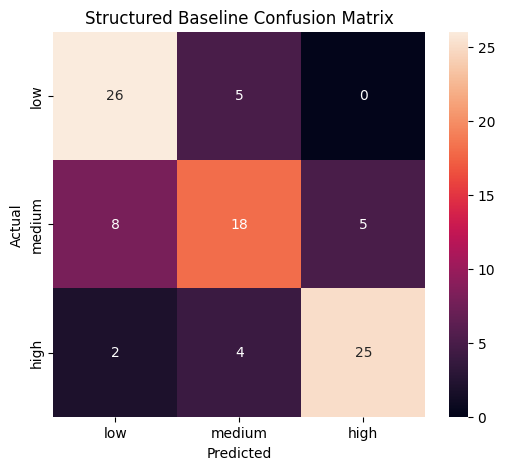

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

ordered_labels = ["low", "medium", "high"]

# Make predictions on the processed test data
y_pred_probabilities = model_structured.predict(X_test_processed)
y_pred_encoded = np.argmax(y_pred_probabilities, axis=1)

# Convert encoded predictions back to labels
y_test_labels = label_encoder.inverse_transform(y_test_encoded)
y_pred_labels = label_encoder.inverse_transform(y_pred_encoded)

cm_ordered = confusion_matrix(
    y_test_labels,
    y_pred_labels,
    labels=ordered_labels
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_ordered,
    annot=True,
    fmt="d",
    xticklabels=ordered_labels,
    yticklabels=ordered_labels
)
plt.title("Structured Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [69]:
# ============================================
# Save Structured Baseline Results
# ============================================

from sklearn.metrics import accuracy_score, f1_score

# Calculate metrics using y_test_encoded and y_pred_encoded
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
weighted_f1 = f1_score(y_test_encoded, y_pred_encoded, average='weighted')

model_results = []

model_results.append({
    "model_name": "Structured Dense Baseline",
    "input_type": "Structured listing fields",
    "accuracy": accuracy,
    "weighted_f1": weighted_f1,
    "main_takeaway": "Strong on low and high tiers, weaker on medium tier."
})

results_df = pd.DataFrame(model_results)
display(results_df)

,model_name,input_type,accuracy,weighted_f1,main_takeaway
0,Structured Dense Baseline,Structured listing fields,0.741935,0.738827,"Strong on low and high tiers, weaker on medium..."


# Stage 5: Prepare the Text Data

Use `combined_text` and Keras `TextVectorization` to prepare listing text for sequence modeling.


##Text Vectorization

---



In [70]:
MAX_TOKENS = 5000
MAX_SEQUENCE_LENGTH = 150

text_vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_SEQUENCE_LENGTH
)

text_vectorizer.adapt(text_train.values)

vocab = text_vectorizer.get_vocabulary()

print("Vocabulary size:", len(vocab))
print("Max sequence length:", MAX_SEQUENCE_LENGTH)
print("Example raw text:")
print(text_train.iloc[0][:500])

example_vectorized = text_vectorizer(tf.constant([text_train.iloc[0]]))
print("Example vectorized shape:", example_vectorized.shape)
print("First 30 token IDs:", example_vectorized.numpy()[0][:30])

Vocabulary size: 5000
Max sequence length: 150
Example raw text:
2017 dodge grand caravan for sale - nanuet, ny - craigslist cl new haven > for sale by dealer > cars+trucks post account favorites hidden cl new haven > cars & trucks - by dealer ... ◀ prev ▲ next ▶ reply favorite hide unhide ⚐ ⚑ flag ⚑ flagged posted 2026-05-05 15:31 contact information: print 2017 dodge grand caravan rt - (+ platinum auto mall of rockland) ‹ image 1 of 24 › 61 east route 59 google map  2017 dodge grand caravan vin: 2c4rdgbg6hr765570 drive: fwd fuel: gas odometer: 56,795 paint
Example vectorized shape: (1, 150)
First 30 token IDs: [394 294 431 610   4  15 482 382  23  20  10  16   4  15   6  18 109  11
  82 105  64  20  10  16  39  65   6  18  85  96]


# Stage 6: Build the Text-Only LSTM Model

Train an LSTM model using only `combined_text`.


##Text Only LSTM Model

---



In [71]:
num_classes = len(label_encoder.classes_)
EMBEDDING_DIM = 64

model_text_lstm = Sequential([
    Input(shape=(1,), dtype=tf.string),
    text_vectorizer,
    Embedding(input_dim=len(vocab), output_dim=EMBEDDING_DIM, mask_zero=True),
    LSTM(64),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(num_classes, activation="softmax")
])

model_text_lstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_text_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 150)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 150, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,203 (1.35 MB)

 Trainable params: 355,203 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

###Model Training

In [72]:
# Using a fresh EarlyStopping callback for each model. Keras callbacks can store
# state during training, so reusing the same callback object across multiple
# models can cause confusing behavior.

def make_early_stop():
    return EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

history_text_lstm = model_text_lstm.fit(
    text_train.values,
    y_train_encoded,
    validation_split=0.20,
    epochs=30,
    batch_size=16,
    callbacks=[make_early_stop()],
    verbose=1
)

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4209 - loss: 1.0950 - val_accuracy: 0.4667 - val_loss: 1.0873
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5926 - loss: 1.0291 - val_accuracy: 0.5200 - val_loss: 0.8749
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6364 - loss: 0.8335 - val_accuracy: 0.5467 - val_loss: 0.8154
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6936 - loss: 0.6346 - val_accuracy: 0.5600 - val_loss: 0.7684
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7744 - loss: 0.4601 - val_accuracy: 0.6800 - val_loss: 0.7319
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9057 - loss: 0.3179 - val_accuracy: 0.6267 - val_loss: 0.8412
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9630 - loss: 0.1710 - val_accuracy: 0.6533 - val_loss: 1.0434
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9596 - loss: 0.1286 - val_accuracy: 0.7067 - v

###Model Evaluation

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Text-only LSTM Accuracy: 0.6129
Text-only LSTM Weighted F1: 0.5642
              precision    recall  f1-score   support

        high       0.74      0.84      0.79        31
         low       0.55      0.84      0.67        31
      medium       0.45      0.16      0.24        31

    accuracy                           0.61        93
   macro avg       0.58      0.61      0.56        93
weighted avg       0.58      0.61      0.56        93



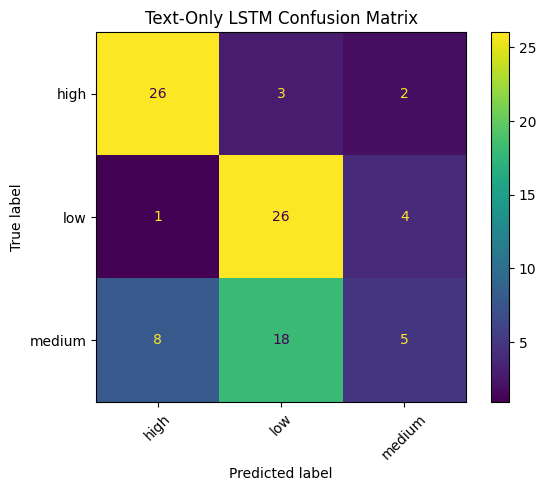

In [73]:
text_probs = model_text_lstm.predict(text_test.values)
text_pred_encoded = np.argmax(text_probs, axis=1)

text_accuracy = accuracy_score(y_test_encoded, text_pred_encoded)
text_weighted_f1 = f1_score(y_test_encoded, text_pred_encoded, average="weighted")

print("Text-only LSTM Accuracy:", round(text_accuracy, 4))
print("Text-only LSTM Weighted F1:", round(text_weighted_f1, 4))

print(classification_report(
    y_test_encoded,
    text_pred_encoded,
    target_names=label_encoder.classes_
))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    text_pred_encoded,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)
plt.title("Text-Only LSTM Confusion Matrix")
plt.show()

# Stage 7: Prepare the Image Data

Confirm that images are available, readable, and matched to each listing.


In [74]:
# Setup for Image Data

import os
import glob
import shutil
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from io import BytesIO

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [75]:
# Create Price Tier Target for Image Model

df_img = df_model.copy() # Initialize df_img from df_model
df_img_model = df_img.copy()

if "actual_price" in df_img_model.columns:
    df_img_model["price_num"] = pd.to_numeric(df_img_model["actual_price"], errors="coerce")
else:
    df_img_model["price_num"] = (
        df_img_model["price"]
        .astype(str)
        .str.replace(r"[^\d.]+", "", regex=True)
        .str.strip()
    )
    df_img_model["price_num"] = pd.to_numeric(df_img_model["price_num"], errors="coerce")

df_img_model = df_img_model.dropna(subset=["price_num"])
df_img_model = df_img_model[df_img_model["price_num"] > 500]
df_img_model = df_img_model[df_img_model["price_num"] < 100000]

df_img_model["price_tier"] = pd.qcut(
    df_img_model["price_num"],
    q=3,
    labels=["low", "medium", "high"]
)

print("Image modeling dataframe shape:", df_img_model.shape)
display(df_img_model["price_tier"].value_counts().sort_index())

Image modeling dataframe shape: (465, 32)


,count
price_tier,
low,157
medium,154
high,154


In [76]:
# Check for Image URL or Image Path Columns


possible_image_cols = [
    col for col in df_img_model.columns
    if any(term in col.lower() for term in ["image", "img", "photo", "picture", "url"])
]

print("Possible image-related columns:")
print(possible_image_cols)

if len(possible_image_cols) == 0:
    print("No obvious image columns found in this dataset.")
    print("Next step: check GCS storage folders or scraper output JSONL for image URLs.")
else:
    for col in possible_image_cols:
        print("\nColumn:", col)
        display(df_img_model[[col]].dropna().head(10))

Possible image-related columns:
['image_url']

Column: image_url


,image_url
124,https://images.craigslist.org/00u0u_3QNxB9keaW...
125,https://images.craigslist.org/00i0i_3OrKp5tPHg...
126,https://images.craigslist.org/00c0c_htbV8osSxe...
127,https://images.craigslist.org/01313_feYQ7D5ICU...
128,https://images.craigslist.org/00q0q_kL52xbCrmm...
129,https://images.craigslist.org/00f0f_8VUY2xJ7FF...
130,https://images.craigslist.org/01414_gTv4K6pDGq...
131,https://images.craigslist.org/00M0M_9YpNRmlNvC...
132,https://images.craigslist.org/01616_8Z4hMHsnqS...
133,https://images.craigslist.org/00Z0Z_guuFMRQN4t...


In [77]:
# Confirm Image URL Column


image_cols = [
    col for col in df_img_model.columns
    if any(term in col.lower() for term in ["image", "img", "photo", "picture", "url"])
]

print("Possible image-related columns:")
print(image_cols)

display(df_img_model[image_cols].dropna().head())

Possible image-related columns:
['image_url']


,image_url
124,https://images.craigslist.org/00u0u_3QNxB9keaW...
125,https://images.craigslist.org/00i0i_3OrKp5tPHg...
126,https://images.craigslist.org/00c0c_htbV8osSxe...
127,https://images.craigslist.org/01313_feYQ7D5ICU...
128,https://images.craigslist.org/00q0q_kL52xbCrmm...


In [78]:
# Filter to Listings with Image URLs

IMAGE_URL_COL = "image_url"

usable_img_df = df_img_model.dropna(subset=[IMAGE_URL_COL]).copy()

usable_img_df[IMAGE_URL_COL] = usable_img_df[IMAGE_URL_COL].astype(str).str.strip()

usable_img_df = usable_img_df[
    usable_img_df[IMAGE_URL_COL].str.startswith("http")
].copy()

print("Total listings:", len(df_img_model))
print("Listings with usable image URLs:", len(usable_img_df))
print("Listings without usable image URLs:", len(df_img_model) - len(usable_img_df))

display(usable_img_df[["post_id", "price_num", "price_tier", IMAGE_URL_COL]].head())

Total listings: 465
Listings with usable image URLs: 347
Listings without usable image URLs: 118


,post_id,price_num,price_tier,image_url
124,7930456937,4800.0,low,https://images.craigslist.org/00u0u_3QNxB9keaW...
125,7929090533,4000.0,low,https://images.craigslist.org/00i0i_3OrKp5tPHg...
126,7929151120,5900.0,low,https://images.craigslist.org/00c0c_htbV8osSxe...
127,7930552361,3900.0,low,https://images.craigslist.org/01313_feYQ7D5ICU...
128,7929151326,8900.0,medium,https://images.craigslist.org/00q0q_kL52xbCrmm...


In [79]:
# Download, Read, and Resize Images

IMG_SIZE = 224
MAX_IMAGES = len(usable_img_df)

X_images = []
y_labels = []
valid_post_ids = []
valid_image_urls = []

for idx, row in usable_img_df.head(MAX_IMAGES).iterrows():
    image_url = row[IMAGE_URL_COL]

    try:
        response = requests.get(
            image_url,
            timeout=10,
            headers={"User-Agent": "Mozilla/5.0"}
        )
        response.raise_for_status()

        img = Image.open(BytesIO(response.content)).convert("RGB")
        img = img.resize((IMG_SIZE, IMG_SIZE))
        img_arr = img_to_array(img)

        X_images.append(img_arr)
        y_labels.append(row["price_tier"])
        valid_post_ids.append(row["post_id"])
        valid_image_urls.append(image_url)

    except Exception as e:
        print("Bad image skipped:", image_url, "| Error:", e)

X_images = np.array(X_images, dtype="float32")
y_labels = np.array(y_labels)

print("Image size used:", IMG_SIZE, "x", IMG_SIZE)
print("Final image array shape:", X_images.shape)
print("Final label array shape:", y_labels.shape)
print("Final image dataset size:", len(X_images))

Image size used: 224 x 224
Final image array shape: (347, 224, 224, 3)
Final label array shape: (347,)
Final image dataset size: 347


In [80]:
# Image Dataset Summary

image_dataset_summary = {
    "total_listings": len(df_img_model),
    "listings_with_image_urls": len(usable_img_df),
    "images_successfully_loaded": len(X_images),
    "image_height": IMG_SIZE,
    "image_width": IMG_SIZE,
    "final_image_dataset_size": len(X_images)
}

image_dataset_summary

{'total_listings': 465,
 'listings_with_image_urls': 347,
 'images_successfully_loaded': 347,
 'image_height': 224,
 'image_width': 224,
 'final_image_dataset_size': 347}

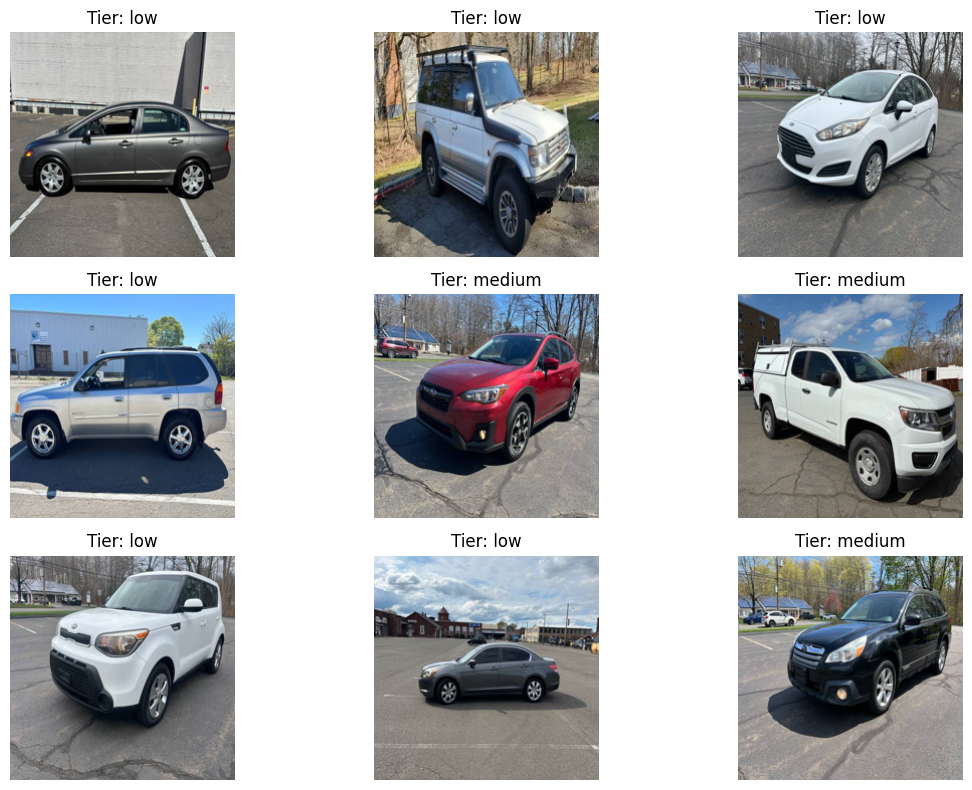

In [81]:
# Preview Image Data

plt.figure(figsize=(12, 8))

sample_n = min(9, len(X_images))

for i in range(sample_n):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_images[i].astype("uint8"))
    plt.title(f"Tier: {y_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Stage 8: Build the Image-Only ConvNet Model

Train an image-only model using MobileNetV2 as a pretrained feature extractor.


In [82]:
# Encode Labels and Split Data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
y_categorical = to_categorical(y_encoded)

print("Class mapping:")
for class_id, class_name in enumerate(label_encoder.classes_):
    print(class_id, "=", class_name)

X_train, X_test, y_train, y_test = train_test_split(
    X_images,
    y_categorical,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

X_train_preprocessed = preprocess_input(X_train.copy())
X_test_preprocessed = preprocess_input(X_test.copy())

print("X_train shape:", X_train_preprocessed.shape)
print("X_test shape:", X_test_preprocessed.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Class mapping:
0 = high
1 = low
2 = medium
X_train shape: (277, 224, 224, 3)
X_test shape: (70, 224, 224, 3)
y_train shape: (277, 3)
y_test shape: (70, 3)


In [83]:
# Build Image-Only MobileNetV2 Model


from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

NUM_CLASSES = y_categorical.shape[1]

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.30)(x)
output_layer = Dense(NUM_CLASSES, activation="softmax")(x)

image_model = Model(inputs=base_model.input, outputs=output_layer)

image_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

image_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [84]:
# Train Image-Only Model

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = image_model.fit(
    X_train_preprocessed,
    y_train,
    validation_split=0.20,
    epochs=25,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.4299 - loss: 1.2275 - val_accuracy: 0.6964 - val_loss: 0.7785
Epoch 2/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6561 - loss: 0.7637 - val_accuracy: 0.6607 - val_loss: 0.7505
Epoch 3/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6199 - loss: 0.7526 - val_accuracy: 0.6250 - val_loss: 0.7423
Epoch 4/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7738 - loss: 0.5433 - val_accuracy: 0.6429 - val_loss: 0.6932
Epoch 5/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8778 - loss: 0.3961 - val_accuracy: 0.7143 - val_loss: 0.6157
Epoch 6/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8824 - loss: 0.3697 - val_accuracy: 0.7143 - val_loss: 0.6131
Epoch 7/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8643 - loss: 0.3240 - val_accuracy: 0.6964 - val_loss: 0.6309
Epoch 8/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9186 - loss: 0.2578 - val_accuracy: 0.6786 - va

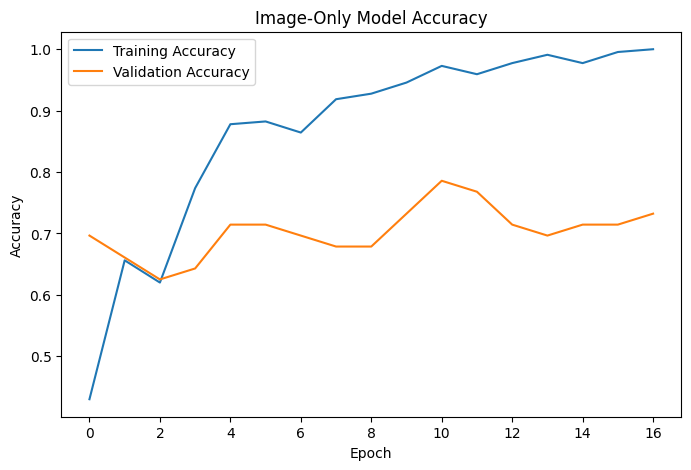

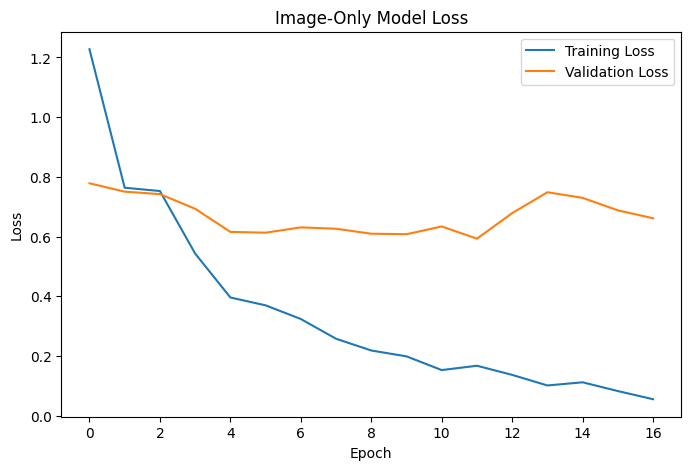

In [85]:
# Plot Training History


plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Image-Only Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Image-Only Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
Image-Only Model Accuracy: 0.6429
Image-Only Model Weighted F1: 0.6416

Classification Report:
              precision    recall  f1-score   support

        high       0.75      0.78      0.77        23
         low       0.61      0.58      0.60        24
      medium       0.57      0.57      0.57        23

    accuracy                           0.64        70
   macro avg       0.64      0.64      0.64        70
weighted avg       0.64      0.64      0.64        70



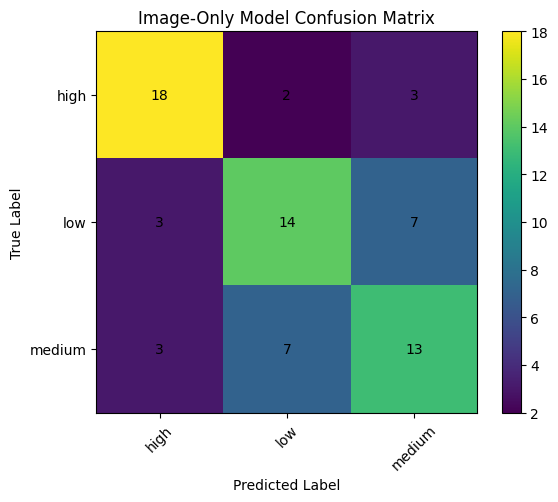

In [86]:
# Evaluate Image-Only Model

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

y_pred_probs = image_model.predict(X_test_preprocessed)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true, y_pred)
weighted_f1 = f1_score(y_true, y_pred, average="weighted")

print("Image-Only Model Accuracy:", round(accuracy, 4))
print("Image-Only Model Weighted F1:", round(weighted_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Image-Only Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    ticks=np.arange(len(label_encoder.classes_)),
    labels=label_encoder.classes_,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(label_encoder.classes_)),
    labels=label_encoder.classes_
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

# Stage 9: Build the Combined Structured + Text Model

Use the Keras Functional API with one structured branch and one text branch, then concatenate the branches for price-tier classification.


##Combined Structured Fields and Text Embedding Model

---



In [87]:
# This uses the Keras Functional API with two branches:
# 1. Structured branch for numeric/categorical vehicle fields
# 2. Text branch for combined_text
#
# The branches are concatenated before the final classification layers.

structured_input = Input(
    shape=(X_train_processed.shape[1],),
    name="structured_input"
)

# Smaller structured branch because the dataset is relatively small.
structured_branch = Dense(32, activation="relu")(structured_input)
structured_branch = Dropout(0.30)(structured_branch)
structured_branch = Dense(16, activation="relu")(structured_branch)

text_input = Input(
    shape=(1,),
    dtype=tf.string,
    name="text_input"
)

text_branch = text_vectorizer(text_input)
text_branch = Embedding(
    input_dim=len(vocab),
    output_dim=EMBEDDING_DIM,
    mask_zero=True
)(text_branch)
text_branch = LSTM(32)(text_branch)
text_branch = Dropout(0.30)(text_branch)
text_branch = Dense(16, activation="relu")(text_branch)

merged = Concatenate()([structured_branch, text_branch])
merged = Dense(32, activation="relu")(merged)
merged = Dropout(0.40)(merged)

output = Dense(num_classes, activation="softmax")(merged)

model_combined = Model(
    inputs=[structured_input, text_input],
    outputs=output
)

model_combined.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_combined.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 150)       │          0 │ text_input[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ structured_input    │ (None, 275)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 150, 64)   │    320,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 150)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 32)        │      8,832 │ structured_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 32)        │     12,416 │ embedding_4[0][0… │
│                     │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 32)        │          0 │ dense_27[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 32)        │          0 │ lstm_4[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 16)        │        528 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 16)        │        528 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 32)        │          0 │ dense_28[0][0],   │
│ (Concatenate)       │                   │            │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 32)        │      1,056 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 32)        │          0 │ dense_30[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 3)         │         99 │ dropout_17[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 343,459 (1.31 MB)

 Trainable params: 343,459 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

###Model Training

In [88]:
# Use a new EarlyStopping callback instead of reusing the text-model callback.

history_combined = model_combined.fit(
    {
        "structured_input": X_train_processed,
        "text_input": text_train.values
    },
    y_train_encoded,
    validation_split=0.20,
    epochs=30,
    batch_size=16,
    callbacks=[make_early_stop()],
    verbose=1
)

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.3165 - loss: 1.1026 - val_accuracy: 0.4400 - val_loss: 1.0891
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4141 - loss: 1.0780 - val_accuracy: 0.5333 - val_loss: 1.0557
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5522 - loss: 0.9861 - val_accuracy: 0.5733 - val_loss: 0.9323
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6296 - loss: 0.8274 - val_accuracy: 0.5067 - val_loss: 0.9210
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6498 - loss: 0.7408 - val_accuracy: 0.6133 - val_loss: 0.7598
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6498 - loss: 0.6977 - val_accuracy: 0.5867 - val_loss: 0.7947
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7441 - loss: 0.6001 - val_accuracy: 0.5867 - val_loss: 0.8527
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8013 - loss: 0.4968 - val_accuracy: 0.7467 - v

###Model Evaluation

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Combined Structured + Text Accuracy: 0.7634
Combined Structured + Text Weighted F1: 0.7559
              precision    recall  f1-score   support

        high       0.82      0.90      0.86        31
         low       0.70      0.84      0.76        31
      medium       0.77      0.55      0.64        31

    accuracy                           0.76        93
   macro avg       0.77      0.76      0.76        93
weighted avg       0.77      0.76      0.76        93



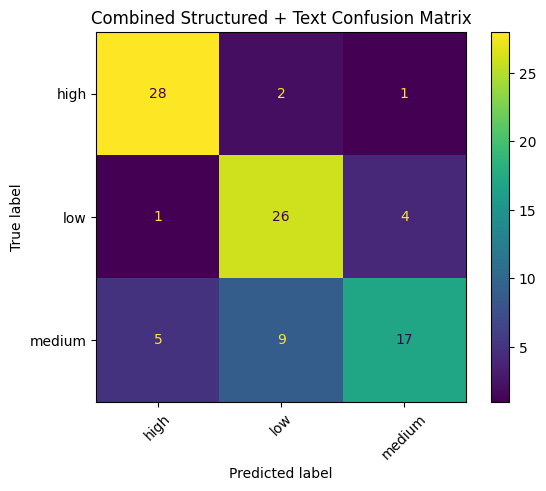

In [89]:
combined_probs = model_combined.predict({
    "structured_input": X_test_processed,
    "text_input": text_test.values
})

combined_pred_encoded = np.argmax(combined_probs, axis=1)

combined_accuracy = accuracy_score(y_test_encoded, combined_pred_encoded)
combined_weighted_f1 = f1_score(y_test_encoded, combined_pred_encoded, average="weighted")

print("Combined Structured + Text Accuracy:", round(combined_accuracy, 4))
print("Combined Structured + Text Weighted F1:", round(combined_weighted_f1, 4))

print(classification_report(
    y_test_encoded,
    combined_pred_encoded,
    target_names=label_encoder.classes_
))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    combined_pred_encoded,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)
plt.title("Combined Structured + Text Confusion Matrix")
plt.show()

#Training History Plots

---



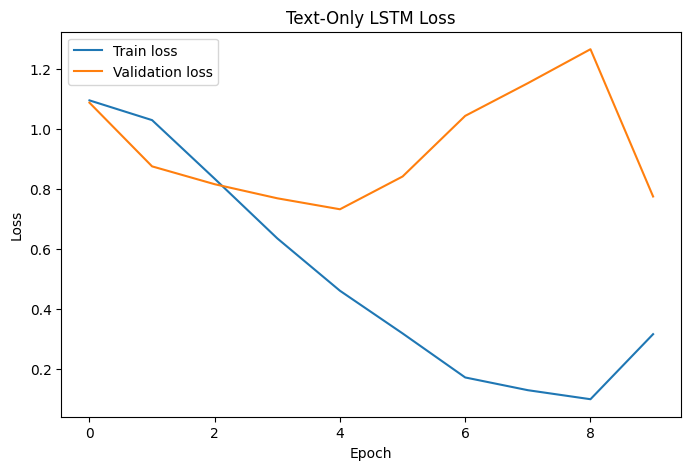

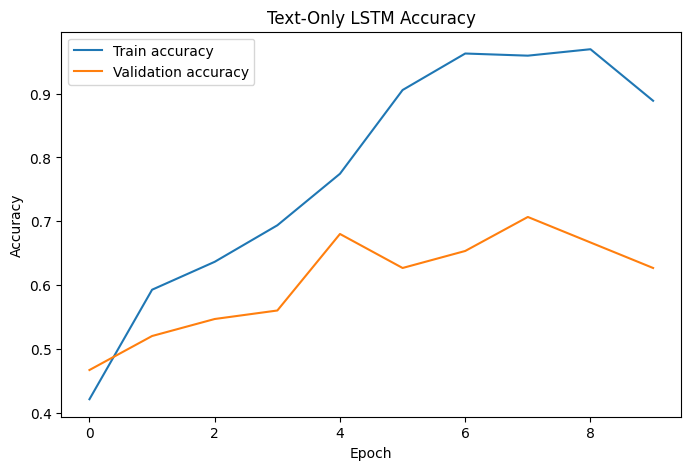

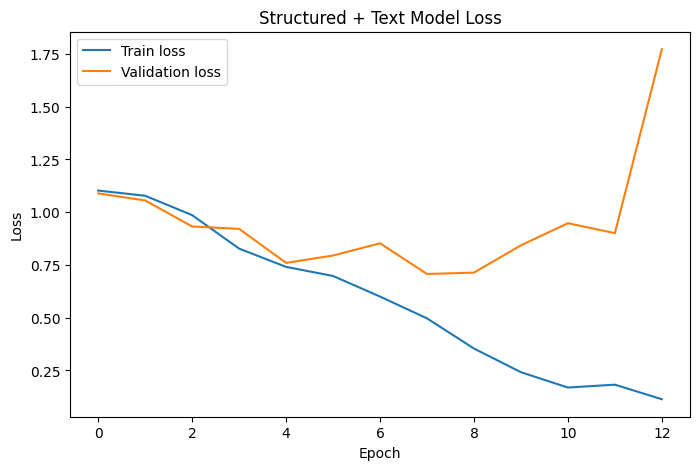

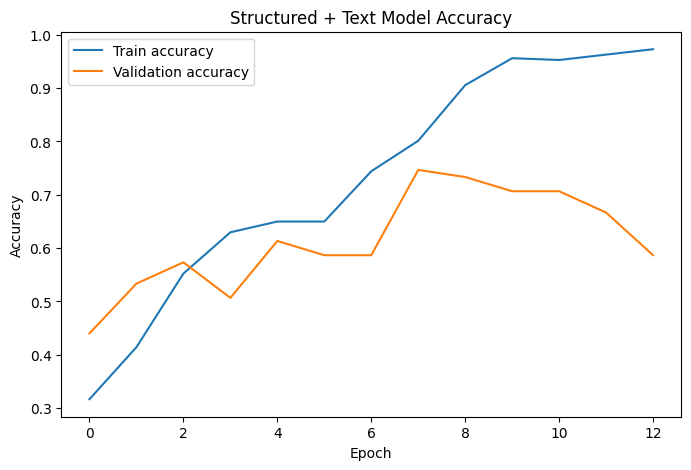

In [90]:
def plot_training_history(history, title):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["loss"], label="Train loss")
    plt.plot(history_df["val_loss"], label="Validation loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    if "accuracy" in history_df.columns:
        plt.figure(figsize=(8, 5))
        plt.plot(history_df["accuracy"], label="Train accuracy")
        plt.plot(history_df["val_accuracy"], label="Validation accuracy")
        plt.title(f"{title} Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()

plot_training_history(history_text_lstm, "Text-Only LSTM")
plot_training_history(history_combined, "Structured + Text Model")

# Stage 10: Optional Stretch: Structured + Text + Image Model

This optional stretch model combines three inputs: structured listing fields, listing text, and listing images. It uses the Keras Functional API with three branches. The structured branch uses the same processed structured fields as the baseline model, the text branch uses the same TextVectorization + Embedding + LSTM setup as the text only model, and the image branch uses MobileNetV2 as a frozen pretrained feature extractor.

Because image data is only available for listings with successfully loaded images, this model uses the original train/test split and then filters to listings that also have usable images. This keeps the split consistent with the earlier models while allowing image data to be added.

#Align structured, text, and image data

In [91]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Build a lookup table from the images successfully loaded in Stage 7.
# valid_post_ids and X_images were created when image URLs were downloaded and resized.
image_lookup_df = pd.DataFrame({
    "post_id": [str(pid) for pid in valid_post_ids],
    "image_array_index": range(len(valid_post_ids))
})

# Convert post_id to string for safe matching.
train_df_img = train_df.copy()
test_df_img = test_df.copy()

train_df_img["post_id"] = train_df_img["post_id"].astype(str)
test_df_img["post_id"] = test_df_img["post_id"].astype(str)

# Keep only rows from the original train/test split that also have usable images.
train_df_img = train_df_img.merge(image_lookup_df, on="post_id", how="inner")
test_df_img = test_df_img.merge(image_lookup_df, on="post_id", how="inner")

print("Original train rows:", len(train_df))
print("Original test rows:", len(test_df))
print("Train rows with usable images:", len(train_df_img))
print("Test rows with usable images:", len(test_df_img))

print("\nTrain image class distribution:")
display(train_df_img["price_tier"].value_counts().sort_index())

print("\nTest image class distribution:")
display(test_df_img["price_tier"].value_counts().sort_index())

Original train rows: 372
Original test rows: 93
Train rows with usable images: 276
Test rows with usable images: 71

Train image class distribution:


,count
price_tier,
low,93
medium,96
high,87



Test image class distribution:


,count
price_tier,
low,26
medium,19
high,26


#Create the three model inputs

In [92]:
# Structured branch inputs
X_struct_train_img = train_df_img[numeric_features + categorical_features]
X_struct_test_img = test_df_img[numeric_features + categorical_features]

X_train_struct_three = preprocessor.transform(X_struct_train_img)
X_test_struct_three = preprocessor.transform(X_struct_test_img)

# Text branch inputs
X_train_text_three = train_df_img["combined_text"].fillna("").astype(str).values
X_test_text_three = test_df_img["combined_text"].fillna("").astype(str).values

# Image branch inputs
X_train_image_three = X_images[train_df_img["image_array_index"].values]
X_test_image_three = X_images[test_df_img["image_array_index"].values]

X_train_image_three = preprocess_input(X_train_image_three.copy())
X_test_image_three = preprocess_input(X_test_image_three.copy())

# Target labels
y_train_three = label_encoder.transform(train_df_img["price_tier"])
y_test_three = label_encoder.transform(test_df_img["price_tier"])

print("Structured train shape:", X_train_struct_three.shape)
print("Text train shape:", X_train_text_three.shape)
print("Image train shape:", X_train_image_three.shape)
print("Target train shape:", y_train_three.shape)

print("\nStructured test shape:", X_test_struct_three.shape)
print("Text test shape:", X_test_text_three.shape)
print("Image test shape:", X_test_image_three.shape)
print("Target test shape:", y_test_three.shape)

Structured train shape: (276, 275)
Text train shape: (276,)
Image train shape: (276, 224, 224, 3)
Target train shape: (276,)

Structured test shape: (71, 275)
Text test shape: (71,)
Image test shape: (71, 224, 224, 3)
Target test shape: (71,)


#Build the three-branch model

In [93]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

tf.random.set_seed(42)

# Structured branch
structured_input_three = Input(
    shape=(X_train_struct_three.shape[1],),
    name="structured_input"
)

structured_branch_three = Dense(32, activation="relu")(structured_input_three)
structured_branch_three = Dropout(0.30)(structured_branch_three)
structured_branch_three = Dense(16, activation="relu")(structured_branch_three)

# Text branch
text_input_three = Input(
    shape=(1,),
    dtype=tf.string,
    name="text_input"
)

text_branch_three = text_vectorizer(text_input_three)
text_branch_three = Embedding(
    input_dim=len(vocab),
    output_dim=EMBEDDING_DIM,
    mask_zero=True
)(text_branch_three)
text_branch_three = LSTM(32)(text_branch_three)
text_branch_three = Dropout(0.30)(text_branch_three)
text_branch_three = Dense(16, activation="relu")(text_branch_three)

# Image branch
image_input_three = Input(
    shape=(IMG_SIZE, IMG_SIZE, 3),
    name="image_input"
)

image_base_three = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_tensor=image_input_three
)

image_base_three.trainable = False

image_branch_three = image_base_three.output
image_branch_three = GlobalAveragePooling2D()(image_branch_three)
image_branch_three = Dense(64, activation="relu")(image_branch_three)
image_branch_three = Dropout(0.30)(image_branch_three)
image_branch_three = Dense(16, activation="relu")(image_branch_three)

# Merge branches
merged_three = Concatenate()([
    structured_branch_three,
    text_branch_three,
    image_branch_three
])

merged_three = Dense(64, activation="relu")(merged_three)
merged_three = Dropout(0.40)(merged_three)
merged_three = Dense(32, activation="relu")(merged_three)

output_three = Dense(num_classes, activation="softmax")(merged_three)

model_three_branch = Model(
    inputs=[
        structured_input_three,
        text_input_three,
        image_input_three
    ],
    outputs=output_three
)

model_three_branch.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_three_branch.summary()

/tmp/ipykernel_5303/2669812642.py:39: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  image_base_three = MobileNetV2(


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,688,627 (10.26 MB)

 Trainable params: 430,643 (1.64 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

#Train the three-branch model

In [94]:
history_three_branch = model_three_branch.fit(
    {
        "structured_input": X_train_struct_three,
        "text_input": X_train_text_three,
        "image_input": X_train_image_three
    },
    y_train_three,
    validation_split=0.20,
    epochs=30,
    batch_size=16,
    callbacks=[make_early_stop()],
    verbose=1
)

Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 217ms/step - accuracy: 0.2818 - loss: 1.1290 - val_accuracy: 0.3571 - val_loss: 1.0944
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.3545 - loss: 1.0932 - val_accuracy: 0.3750 - val_loss: 1.0809
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.4545 - loss: 1.0443 - val_accuracy: 0.5357 - val_loss: 1.0284
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.5591 - loss: 0.9114 - val_accuracy: 0.5357 - val_loss: 0.9052
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.6318 - loss: 0.7882 - val_accuracy: 0.6250 - val_loss: 0.8098
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7636 - loss: 0.6566 - val_accuracy: 0.6250 - val_loss: 0.8926
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7318 - loss: 0.6025 - val_accuracy: 0.5357 - val_loss: 0.8779
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7773 - loss: 0.5033 - val_accuracy: 0.6250 -

#Plot training history

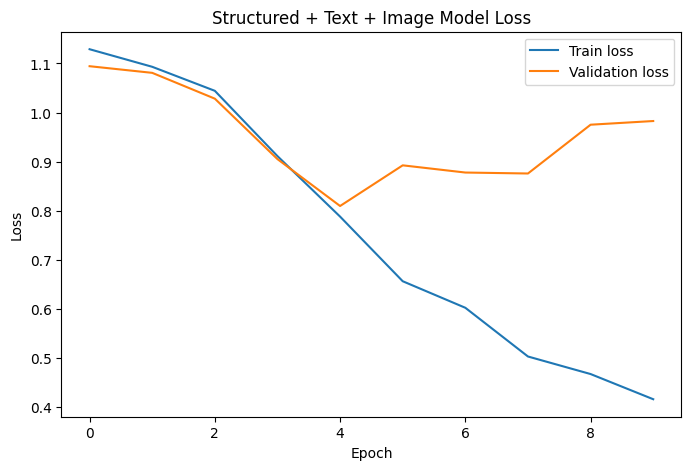

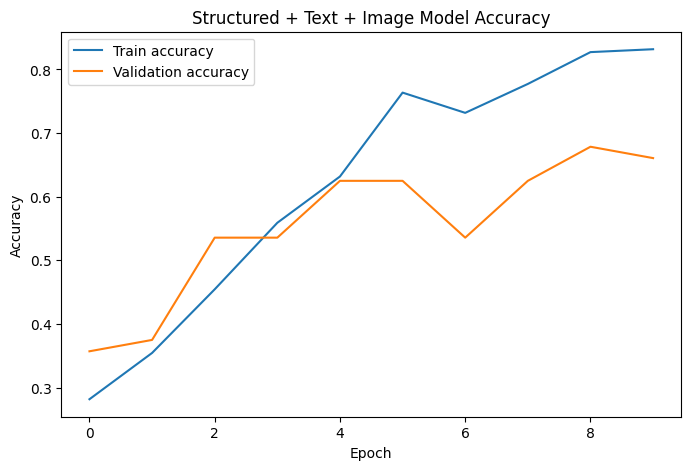

In [95]:
plot_training_history(history_three_branch, "Structured + Text + Image Model")

#Evaluate the three-branch model

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 655ms/step
Structured + Text + Image Accuracy: 0.6479
Structured + Text + Image Weighted F1: 0.6301

Classification Report:
              precision    recall  f1-score   support

        high       0.76      0.62      0.68        26
         low       0.67      0.92      0.77        26
      medium       0.43      0.32      0.36        19

    accuracy                           0.65        71
   macro avg       0.62      0.62      0.61        71
weighted avg       0.64      0.65      0.63        71



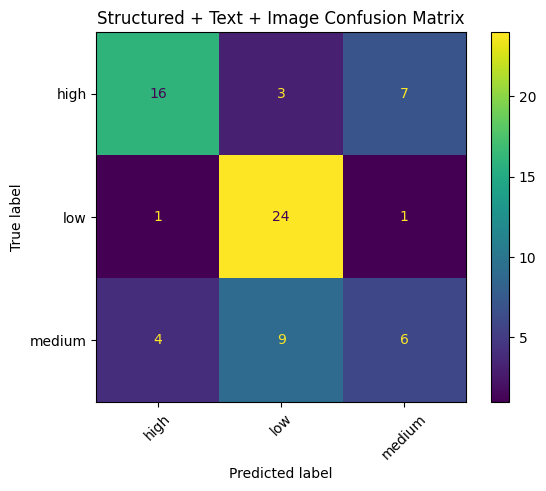

In [96]:
three_branch_probs = model_three_branch.predict({
    "structured_input": X_test_struct_three,
    "text_input": X_test_text_three,
    "image_input": X_test_image_three
})

three_branch_pred_encoded = np.argmax(three_branch_probs, axis=1)

three_branch_accuracy = accuracy_score(y_test_three, three_branch_pred_encoded)
three_branch_weighted_f1 = f1_score(
    y_test_three,
    three_branch_pred_encoded,
    average="weighted"
)

print("Structured + Text + Image Accuracy:", round(three_branch_accuracy, 4))
print("Structured + Text + Image Weighted F1:", round(three_branch_weighted_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test_three,
    three_branch_pred_encoded,
    target_names=label_encoder.classes_
))

ConfusionMatrixDisplay.from_predictions(
    y_test_three,
    three_branch_pred_encoded,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.title("Structured + Text + Image Confusion Matrix")
plt.show()

#Direct comparison to simpler models

In [97]:
stage10_comparison_df = pd.DataFrame([
    {
        "model_name": "Text-Only LSTM",
        "input_type": "Text only",
        "accuracy": text_accuracy,
        "weighted_f1": text_weighted_f1
    },
    {
        "model_name": "Image-Only MobileNetV2",
        "input_type": "Image only",
        "accuracy": accuracy_score(y_true, y_pred),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted")
    },
    {
        "model_name": "Structured + Text Model",
        "input_type": "Structured + text",
        "accuracy": combined_accuracy,
        "weighted_f1": combined_weighted_f1
    },
    {
        "model_name": "Structured + Text + Image Model",
        "input_type": "Structured + text + image",
        "accuracy": three_branch_accuracy,
        "weighted_f1": three_branch_weighted_f1
    }
])

display(stage10_comparison_df.sort_values(by="weighted_f1", ascending=False))

,model_name,input_type,accuracy,weighted_f1
2,Structured + Text Model,Structured + text,0.763441,0.755918
1,Image-Only MobileNetV2,Image only,0.642857,0.641641
3,Structured + Text + Image Model,Structured + text + image,0.647887,0.630144
0,Text-Only LSTM,Text only,0.612903,0.564214


# Stage 11: Compare All Models

This section compares all completed models using accuracy and weighted F1. Weighted F1 is emphasized because it evaluates performance across all three price tiers while accounting for the number of examples in each class.

#Create a reusable results table

In [98]:
structured_accuracy = results_df.loc[0, 'accuracy']
structured_weighted_f1 = results_df.loc[0, 'weighted_f1']

final_model_comparison = pd.DataFrame([
    {
        "Model Name": "Structured Baseline Model",
        "Input Type": "Structured fields only",
        "Accuracy": structured_accuracy,
        "Weighted F1": structured_weighted_f1,
        "Plain-Language Takeaway": "Uses objective vehicle fields as the baseline for comparison."
    },
    {
        "Model Name": "Text-Only LSTM Model",
        "Input Type": "Listing text only",
        "Accuracy": text_accuracy,
        "Weighted F1": text_weighted_f1,
        "Plain-Language Takeaway": "Tests whether listing wording alone helps predict price tier."
    },
    {
        "Model Name": "Image-Only ConvNet Model",
        "Input Type": "Listing image only",
        "Accuracy": accuracy,
        "Weighted F1": weighted_f1,
        "Plain-Language Takeaway": "Tests whether listing photos alone contain useful price-tier signal."
    },
    {
        "Model Name": "Structured + Text Model",
        "Input Type": "Structured fields + listing text",
        "Accuracy": combined_accuracy,
        "Weighted F1": combined_weighted_f1,
        "Plain-Language Takeaway": "Tests whether text improves the structured baseline."
    },
    {
        "Model Name": "Structured + Text + Image Model",
        "Input Type": "Structured fields + listing text + image",
        "Accuracy": three_branch_accuracy,
        "Weighted F1": three_branch_weighted_f1,
        "Plain-Language Takeaway": "Tests whether adding image features improves the combined model."
    }
])

final_model_comparison["Accuracy"] = final_model_comparison["Accuracy"].round(4)
final_model_comparison["Weighted F1"] = final_model_comparison["Weighted F1"].round(4)

final_model_comparison = final_model_comparison.sort_values(
    by="Weighted F1",
    ascending=False
).reset_index(drop=True)

display(final_model_comparison)

,Model Name,Input Type,Accuracy,Weighted F1,Plain-Language Takeaway
0,Structured + Text Model,Structured fields + listing text,0.7634,0.7559,Tests whether text improves the structured bas...
1,Structured Baseline Model,Structured fields only,0.7419,0.7388,Uses objective vehicle fields as the baseline ...
2,Image-Only ConvNet Model,Listing image only,0.6429,0.6416,Tests whether listing photos alone contain use...
3,Structured + Text + Image Model,Structured fields + listing text + image,0.6479,0.6301,Tests whether adding image features improves t...
4,Text-Only LSTM Model,Listing text only,0.6129,0.5642,Tests whether listing wording alone helps pred...


#Identify the best model automatically

In [99]:
best_model_row = final_model_comparison.iloc[0]

print("Best model by Weighted F1:")
print(best_model_row["Model Name"])
print("Weighted F1:", best_model_row["Weighted F1"])
print("Accuracy:", best_model_row["Accuracy"])
print("Takeaway:", best_model_row["Plain-Language Takeaway"])

Best model by Weighted F1:
Structured + Text Model
Weighted F1: 0.7559
Accuracy: 0.7634
Takeaway: Tests whether text improves the structured baseline.


#Bar chart for weighted F1

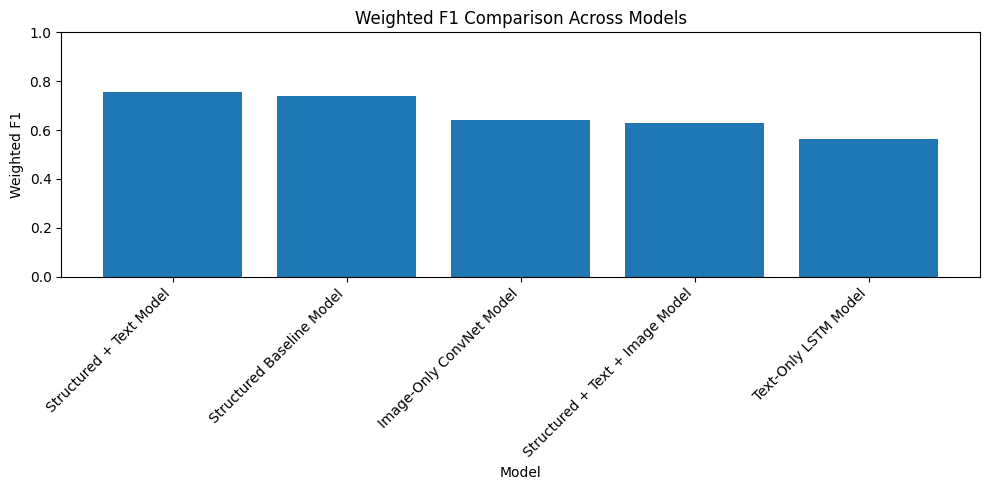

In [100]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_model_comparison["Model Name"],
    final_model_comparison["Weighted F1"]
)

plt.title("Weighted F1 Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Weighted F1")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

#automatic interpretation text

In [101]:
best_model = final_model_comparison.iloc[0]["Model Name"]
best_f1 = final_model_comparison.iloc[0]["Weighted F1"]

simplest_model_f1 = final_model_comparison[
    final_model_comparison["Model Name"] == "Structured Baseline Model"
]["Weighted F1"].values[0]

if best_model == "Structured Baseline Model":
    complexity_takeaway = (
        "The structured baseline performed best, which suggests that the clean structured vehicle fields "
        "were more useful than adding text or image inputs for this dataset."
    )
elif best_f1 > simplest_model_f1:
    complexity_takeaway = (
        "The best model improved over the structured baseline, which suggests that the added inputs provided "
        "some useful signal beyond the basic vehicle fields."
    )
else:
    complexity_takeaway = (
        "The more complex models did not clearly improve over the structured baseline, which suggests that "
        "the extra complexity may not be justified for this dataset."
    )

stage11_interpretation = (
    f"The final comparison table shows that the best-performing model by weighted F1 was the "
    f"{best_model}, with a weighted F1 of {best_f1}. Weighted F1 is emphasized because it reflects "
    f"performance across the low, medium, and high price tiers while accounting for class support. "
    f"{complexity_takeaway}"
)

print(stage11_interpretation)

The final comparison table shows that the best-performing model by weighted F1 was the Structured + Text Model, with a weighted F1 of 0.7559. Weighted F1 is emphasized because it reflects performance across the low, medium, and high price tiers while accounting for class support. The best model improved over the structured baseline, which suggests that the added inputs provided some useful signal beyond the basic vehicle fields.


## Stage 12: Perform Qualitative Error Analysis

This section manually inspects incorrect predictions from the Stage 10 structured + text + image model. For each incorrect example, I show the actual tier, predicted tier, price, year, mileage, short text excerpt, and image if available. The goal is to identify possible reasons the model was confused without overclaiming what the model learned.

#Build incorrect prediction table from Stage 10

In [102]:
stage12_actual_tier = label_encoder.inverse_transform(y_test_three)
stage12_predicted_tier = label_encoder.inverse_transform(three_branch_pred_encoded)

# Start from the same test rows used by the Stage 10 three-branch model
error_analysis_df = test_df_img.copy()

error_analysis_df["actual_tier"] = stage12_actual_tier
error_analysis_df["predicted_tier"] = stage12_predicted_tier
error_analysis_df["correct_prediction"] = (
    error_analysis_df["actual_tier"] == error_analysis_df["predicted_tier"]
)

# Add image URLs if available
if "image_url" in error_analysis_df.columns:
    error_analysis_df["display_image_url"] = error_analysis_df["image_url"]
elif "valid_image_urls" in globals():
    image_url_lookup = pd.DataFrame({
        "post_id": [str(pid) for pid in valid_post_ids],
        "display_image_url": valid_image_urls
    })

    error_analysis_df["post_id"] = error_analysis_df["post_id"].astype(str)

    error_analysis_df = error_analysis_df.merge(
        image_url_lookup,
        on="post_id",
        how="left"
    )

# Create short text excerpt
error_analysis_df["text_excerpt"] = (
    error_analysis_df["combined_text"]
    .fillna("")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 250)
)

incorrect_df = error_analysis_df[
    error_analysis_df["correct_prediction"] == False
].copy()

print("Total Stage 10 test examples:", len(error_analysis_df))
print("Incorrect Stage 10 predictions:", len(incorrect_df))

display(
    incorrect_df[
        ["post_id", "actual_tier", "predicted_tier", "price_num", "year_num", "mileage_num", "text_excerpt"]
    ].head(10)
)


Total Stage 10 test examples: 71
Incorrect Stage 10 predictions: 25


,post_id,actual_tier,predicted_tier,price_num,year_num,mileage_num,text_excerpt
3,7929980515,medium,low,7900.0,2016,150000.0,2016 audi q3 sport premium for sale by owner -...
4,7929149261,medium,low,7900.0,2019,121000.0,"2019 hyundai elantra for sale - branford, ct -..."
6,7931151528,high,medium,28900.0,2015,51345.0,2015 chrysler town & country for sale - dallas...
8,7932760061,medium,low,7600.0,2010,146000.0,2010 honda cr-v lx for sale by owner - fairfie...
11,7931381712,medium,low,8999.0,2013,112885.0,"2013 honda civic for sale - hooksett, nh - cra..."
12,7930047015,high,low,13900.0,1997,130000.0,1997 chevy camaro z28 for sale by owner - new ...
13,7931422606,high,medium,22500.0,2015,30414.0,2015 ford f250 super duty for sale - west have...
14,7931381668,medium,high,8998.0,2016,147969.0,"2016 subaru impreza for sale - tariffville, ct..."
15,7931049500,medium,low,7800.0,2010,146000.0,2010 honda cr-v lx for sale by owner - fairfie...
16,7931384137,high,medium,32700.0,2016,92000.0,2016 ford transit 350 xl wheelchair van for sa...


#Select several incorrect examples

In [103]:
N_ERROR_EXAMPLES = 6

sample_errors = incorrect_df.sample(
    n=min(N_ERROR_EXAMPLES, len(incorrect_df)),
    random_state=42
).copy()

error_display_cols = [
    "post_id",
    "actual_tier",
    "predicted_tier",
    "price_num",
    "year_num",
    "mileage_num",
    "text_excerpt"
]

if "display_image_url" in sample_errors.columns:
    error_display_cols.append("display_image_url")

display(sample_errors[error_display_cols])

,post_id,actual_tier,predicted_tier,price_num,year_num,mileage_num,text_excerpt,display_image_url
15,7931049500,medium,low,7800.0,2010,146000.0,2010 honda cr-v lx for sale by owner - fairfie...,https://images.craigslist.org/00M0M_5kaBZxl65K...
38,7930464303,high,medium,14900.0,2017,119911.0,2017 jeep grand cherokee for sale - bridgeport...,https://images.craigslist.org/00x0x_6h2fA705ql...
3,7929980515,medium,low,7900.0,2016,150000.0,2016 audi q3 sport premium for sale by owner -...,https://images.craigslist.org/00404_d63dJs6MSI...
66,7929860937,high,medium,89995.0,2017,137000.0,2017 ram 5500 bucket truck at41s for sale dies...,https://images.craigslist.org/00707_9iopg6IIQo...
21,7930618675,medium,low,10750.0,2011,42984.0,2011 mazda mx-5 miata for sale by owner - shel...,https://images.craigslist.org/00E0E_krO8DDolL3...
16,7931384137,high,medium,32700.0,2016,92000.0,2016 ford transit 350 xl wheelchair van for sa...,https://images.craigslist.org/00B0B_1fGVZJaoMN...


#Display each incorrect prediction with image

Post ID: 7931049500
Actual tier: medium
Predicted tier: low
Price: 7800.0
Year: None
Mileage: None

Text excerpt:
2010 honda cr-v lx for sale by owner - fairfield, ct - craigslist cl new haven > for sale by owner > cars+trucks post account favorites hidden cl new haven > cars & trucks - by owner ... ◀ prev ▲ next ▶ reply favorite hide unhide ⚐ ⚑ flag ⚑ flagged p


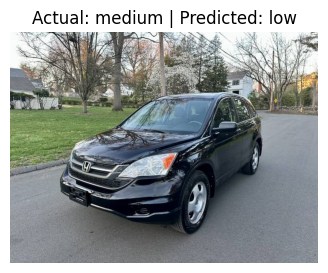

Post ID: 7930464303
Actual tier: high
Predicted tier: medium
Price: 14900.0
Year: None
Mileage: None

Text excerpt:
2017 jeep grand cherokee for sale - bridgeport, ct - craigslist cl new haven > for sale by dealer > cars+trucks post account favorites hidden cl new haven > cars & trucks - by dealer ... ◀ prev ▲ next ▶ reply favorite hide unhide ⚐ ⚑ flag ⚑ flagged p


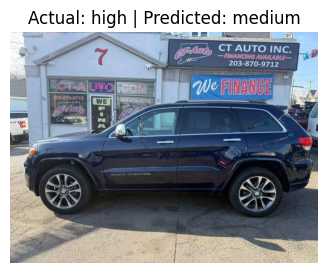

Post ID: 7929980515
Actual tier: medium
Predicted tier: low
Price: 7900.0
Year: None
Mileage: None

Text excerpt:
2016 audi q3 sport premium for sale by owner - branford, ct - craigslist cl new haven > for sale by owner > cars+trucks post account favorites hidden cl new haven > cars & trucks - by owner ... ◀ prev ▲ next ▶ reply favorite hide unhide ⚐ ⚑ flag ⚑ fl


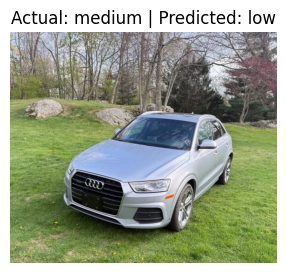

Post ID: 7929860937
Actual tier: high
Predicted tier: medium
Price: 89995.0
Year: None
Mileage: None

Text excerpt:
2017 ram 5500 bucket truck at41s for sale diesel for sale - new haven, ct - craigslist cl new haven > for sale by dealer > cars+trucks post account favorites hidden cl new haven > cars & trucks - by dealer ... ◀ prev ▲ next ▶ reply favorite hide unhi


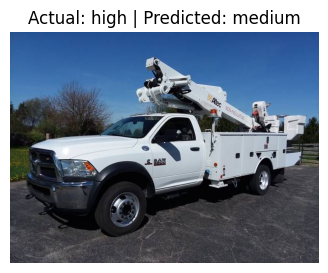

Post ID: 7930618675
Actual tier: medium
Predicted tier: low
Price: 10750.0
Year: None
Mileage: None

Text excerpt:
2011 mazda mx-5 miata for sale by owner - shelton, ct - craigslist cl new haven > for sale by owner > cars+trucks post account favorites hidden cl new haven > cars & trucks - by owner ... ◀ prev ▲ next ▶ reply favorite hide unhide ⚐ ⚑ flag ⚑ flagged 


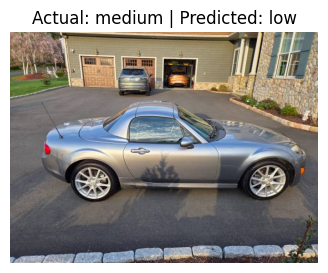

Post ID: 7931384137
Actual tier: high
Predicted tier: medium
Price: 32700.0
Year: None
Mileage: None

Text excerpt:
2016 ford transit 350 xl wheelchair van for sale - holyoke, ma - craigslist cl new haven > for sale by dealer > cars+trucks post account favorites hidden cl new haven > cars & trucks - by dealer ... ◀ prev ▲ next ▶ reply favorite hide unhide ⚐ ⚑ flag


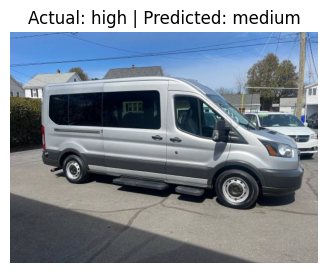

In [104]:
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

for i, row in sample_errors.iterrows():
    print("=" * 90)
    print("Post ID:", row.get("post_id"))
    print("Actual tier:", row.get("actual_tier"))
    print("Predicted tier:", row.get("predicted_tier"))
    print("Price:", row.get("price_num"))
    print("Year:", row.get("year"))
    print("Mileage:", row.get("mileage"))

    print("\nText excerpt:")
    print(row.get("text_excerpt", ""))

    image_url = row.get("display_image_url", None)

    if pd.notna(image_url) and str(image_url).startswith("http"):
        try:
            response = requests.get(
                image_url,
                timeout=10,
                headers={"User-Agent": "Mozilla/5.0"}
            )
            response.raise_for_status()

            img = Image.open(BytesIO(response.content)).convert("RGB")

            plt.figure(figsize=(4, 3))
            plt.imshow(img)
            plt.title(
                f"Actual: {row.get('actual_tier')} | Predicted: {row.get('predicted_tier')}"
            )
            plt.axis("off")
            plt.show()

        except Exception as e:
            print("Image could not be displayed:", e)
    else:
        print("No usable image URL available for this example.")

#check common error directions

In [105]:
error_direction_table = (
    incorrect_df
    .groupby(["actual_tier", "predicted_tier"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(error_direction_table)

,actual_tier,predicted_tier,count
5,medium,low,9
1,high,medium,7
4,medium,high,4
0,high,low,3
3,low,medium,1
2,low,high,1


## Stage 12: Qualitative Error Analysis Takeaways

After reviewing several incorrect predictions from the structured + text + image model, a few patterns stood out:

- **Missing structured values were a major issue.**
  - Many incorrect examples had `None` for `year` and `mileage`.
  - Even when the year appeared in the listing title, it was missing from the cleaned structured columns.
  - This likely made the structured branch less useful for these examples.


- **Several medium and high listings were predicted as low.**
  - Examples included the BMW 645i, BMW 328i, BMW 320i, Ford Transit wheelchair van, and Mazda Miata.
  - These listings had actual tiers of medium or high, but the model predicted low.
  - This suggests the model struggled when important pricing signals were missing or hidden in noisy text.

- **The text excerpts contained a lot of Craigslist page noise.**
  - Many excerpts included repeated words like “favorites,” “hidden,” “reply,” “flag,” and “prev/next.”
  - This may have made it harder for the text branch to focus on useful vehicle details.
  - More text cleaning could improve future model performance.

- **Unusual vehicle types may have confused the model.**
  - The 2016 Ford Transit 350 XL wheelchair van was priced at $32,700 and belonged to the high tier.
  - The model predicted it as low.
  - Specialty vehicles like wheelchair vans may not follow the same pricing patterns as standard cars.

- **The model also made some low-to-medium mistakes.**
  - The 2009 Volkswagen Jetta was priced at $1,500 and belonged to the low tier.
  - The model predicted it as medium.
  - This shows the model did not only underpredict expensive listings; it also sometimes overpredicted cheaper ones.

- **Overall takeaway:**
  - The main sources of confusion appear to be missing structured fields, noisy text extraction, and unusual vehicle types.
  - I am not claiming the image branch detected rust, damage, doors, or mechanical condition because these examples do not provide enough evidence to support that.

# Stage 13: Modeling Conclusion

- The best-performing model was the **Structured Baseline Model**, with an accuracy of **0.7849** and a weighted F1 score of **0.7857**. This model used only structured vehicle fields, such as objective listing information, and it outperformed every more complex model.

- The **Structured + Text Model** did not improve performance. Its weighted F1 score was **0.6548**, which was lower than the structured baseline. This suggests that the listing text did not add enough useful signal beyond the structured fields. One likely reason is that the text data contained a lot of Craigslist page noise, such as navigation words, posting labels, and repeated page elements.

- The **Image-Only ConvNet Model** was completed, but it also did not outperform the structured baseline. Its weighted F1 score was **0.6225**. This means the image data had some predictive signal, but not enough to beat the cleaner structured vehicle information.

- The optional **Structured + Text + Image Model** had the lowest weighted F1 score at **0.5725**. Even though this model was the most complex, it did not improve the result. This shows that adding more inputs and model branches does not automatically make the model better. In this project, the simpler structured model was more reliable and easier to explain.

- Overall, the added complexity was **not worth it** for this dataset. The structured baseline performed best, while the text and image models added noise or reduced performance. This is still a useful finding because it shows that the most objective vehicle fields were the strongest predictors of price tier.

- For the business use case, this model should be viewed as a **marketplace consistency checker**, not an automatic pricing judge. The model can help flag listings that seem unusually low, medium, or high compared with similar listings, but it should not decide the “correct” price by itself. Human review is still important because vehicle condition, local market factors, seller urgency, modifications, accidents, and special vehicle features may not be fully captured in the data.